# Classical Reservoir Computing

## What is Reservoir Computing?

**Reservoir Computing (RC)** is a framework for computation that uses a fixed, high-dimensional dynamical system (the **reservoir**) to transform input signals into a rich feature space. Only the **output layer (readout)** is trained — making it extremely efficient compared to fully trained recurrent neural networks like LSTMs.

### Key Components:
| Component | Description |
|-----------|-------------|
| **Input weights W_in** | Projects input into the reservoir (fixed, random) |
| **Reservoir W** | Sparse, random recurrent network (fixed, random) |
| **Readout W_out** | Linear layer — the ONLY part that is trained |

### The update equation:
$$\mathbf{x}(t+1) = (1-\alpha)\mathbf{x}(t) + \alpha \cdot \tanh(W_{in}\mathbf{u}(t) + W\mathbf{x}(t))$$

Where:
- $\mathbf{x}(t)$ = reservoir state vector
- $\mathbf{u}(t)$ = input at time $t$
- $\alpha$ = leaking rate

### Task: Time-series prediction using the **Mackey-Glass** chaotic series

## 1. Imports and Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.integrate import odeint

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

Libraries loaded successfully!


## 2. Generate Data: Mackey-Glass Chaotic Time Series

The **Mackey-Glass equation** is a classical benchmark. It is a delay differential equation that exhibits rich chaotic behavior:

$$\frac{dx}{dt} = \frac{\beta x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t)$$

With parameters $\beta=0.2$, $\gamma=0.1$, $n=10$, $\tau=17$ it produces a chaotic attractor.

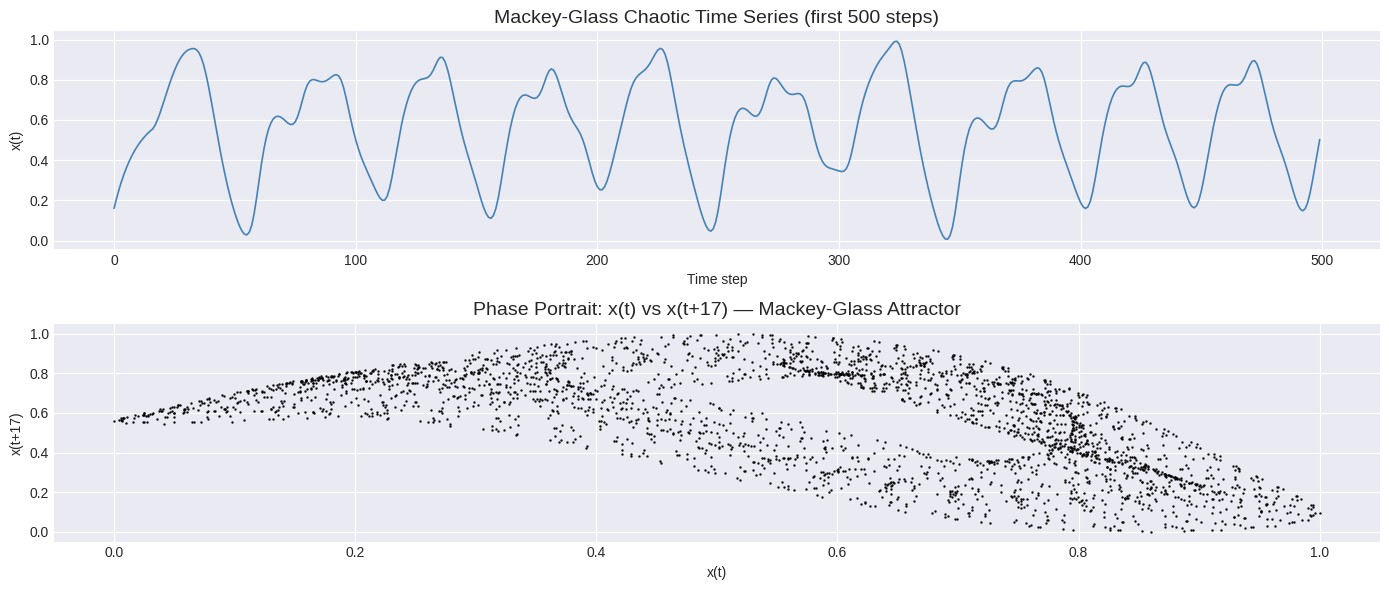

Data shape: (3000,)


In [ ]:
def mackey_glass(n_samples=3000, tau=17, beta=0.2, gamma=0.1, n=10, dt=1.0):
    """
    Generate Mackey-Glass time series using Euler integration with delay.
    This is a standard chaotic benchmark.
    """
    history_len = max(tau, 50)
    history = 0.5 * np.ones(history_len)  # initial condition
    x = list(history)

    for i in range(n_samples):
        x_now = x[-1]
        x_tau = x[-tau] if len(x) >= tau else 0.5
        dx = beta * x_tau / (1 + x_tau**n) - gamma * x_now
        x.append(x_now + dt * dx)

    return np.array(x[history_len:])

# Generate the time series
data = mackey_glass(n_samples=3000)

# Normalize to [0, 1]
data = (data - data.min()) / (data.max() - data.min())

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(data[:500], color='steelblue', linewidth=1.2)
axes[0].set_title('Mackey-Glass Chaotic Time Series (first 500 steps)', fontsize=14)
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('x(t)')

# Phase portrait (x(t) vs x(t+17)) — the attractor
axes[1].plot(data[:-17], data[17:], '.', color='black', alpha=0.9, markersize=1.5)
axes[1].set_title('Phase Portrait: x(t) vs x(t+17) — Mackey-Glass Attractor', fontsize=14)
axes[1].set_xlabel('x(t)')
axes[1].set_ylabel('x(t+17)')

plt.tight_layout()
plt.show()
print(f'Data shape: {data.shape}')

## 3. Prepare Train/Test Splits

The task: **predict $x(t+1)$ given $x(t)$** — a one-step-ahead prediction.

In [5]:
# Input u(t) and target y(t) = x(t+1)
u = data[:-1].reshape(-1, 1)  # inputs
y = data[1:]                   # targets (one step ahead)

n_train = 2000
n_test  = len(u) - n_train

u_train, u_test = u[:n_train], u[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(f'Training samples : {n_train}')
print(f'Test samples     : {n_test}')

Training samples : 2000
Test samples     : 999


## 4. Build the Classical Echo State Network (ESN)

An **Echo State Network** is the most common implementation of Reservoir Computing.

### **Echo State Property (ESP)**
The reservoir must "forget" its initial conditions over time. This is guaranteed when the **spectral radius** $\rho(W) < 1$:

$$W \leftarrow W \cdot \frac{\rho_{target}}{\rho(W)}$$

In [ ]:
class EchoStateNetwork:
    """
    Echo State Network (ESN) — a classical Reservoir Computing architecture.

    Architecture:
        Input → [Fixed Random Reservoir] → Readout (trained)
    """

    def __init__(self, n_reservoir=500, spectral_radius=0.95,
                 sparsity=0.1, input_scaling=1.0, leaking_rate=1.0,
                 n_inputs=1, n_outputs=1, washout=100, ridge_alpha=1e-6):
        """
        Parameters:
        -----------
        n_reservoir    : Number of reservoir neurons
        spectral_radius: Controls the memory of the reservoir (< 1 for ESP)
        sparsity       : Fraction of zero connections in W
        input_scaling  : Scales the input weights
        leaking_rate   : Alpha in the update equation (1 = no leaking)
        washout        : Initial steps to discard (remove transient effects)
        ridge_alpha    : Regularization for Ridge regression readout
        """
        self.N = n_reservoir
        self.sr = spectral_radius
        self.sparsity = sparsity
        self.input_scaling = input_scaling
        self.alpha = leaking_rate
        self.n_in = n_inputs
        self.n_out = n_outputs
        self.washout = washout
        self.ridge_alpha = ridge_alpha

        self._build_reservoir()

    def _build_reservoir(self):
        """Initialize fixed random weights."""
        # Input weight matrix W_in: shape (N, n_inputs)
        self.W_in = (np.random.rand(self.N, self.n_in) - 0.5) * self.input_scaling

        # Reservoir weight matrix W: sparse random matrix
        W = np.random.rand(self.N, self.N) - 0.5
        W[np.random.rand(self.N, self.N) > self.sparsity] = 0

        # Scale to desired spectral radius
        eigenvalues = np.linalg.eigvals(W)
        current_sr = np.max(np.abs(eigenvalues))
        self.W = W * (self.sr / current_sr)

        print(f'Reservoir built:')
        print(f'  Neurons        : {self.N}')
        print(f'  Spectral radius: {np.max(np.abs(np.linalg.eigvals(self.W))):.4f}')
        print(f'  Sparsity       : {(self.W == 0).mean():.2%}')

    def _run_reservoir(self, u):
        """Drive the reservoir with input signal u, collect states."""
        T = len(u)
        states = np.zeros((T, self.N))
        x = np.zeros(self.N)  # initial reservoir state

        for t in range(T):
            # ESN update equation with leaky integration
            x = ((1 - self.alpha) * x
                 + self.alpha * np.tanh(self.W_in @ u[t] + self.W @ x))
            states[t] = x

        return states

    def fit(self, u_train, y_train):
        """Collect reservoir states and train the readout with Ridge regression."""
        # Run reservoir
        states = self._run_reservoir(u_train)

        # Discard washout period (remove initial transients)
        states_fit = states[self.washout:]
        y_fit = y_train[self.washout:]

        # Concatenate input with states for extended state vector
        extended_states = np.hstack([states_fit, u_train[self.washout:]])

        # Train linear readout — THIS IS THE ONLY TRAINED PART!
        self.readout = Ridge(alpha=self.ridge_alpha, fit_intercept=True)
        self.readout.fit(extended_states, y_fit)

        train_pred = self.readout.predict(extended_states)
        train_mse = mean_squared_error(y_fit, train_pred)
        print(f'Training MSE: {train_mse:.6f}')
        return self

    def predict(self, u_test):
        """Run reservoir on test data and predict."""
        states = self._run_reservoir(u_test)
        extended_states = np.hstack([states, u_test])
        return self.readout.predict(extended_states)

Reservoir built:
  Neurons        : 1000
  Spectral radius: 0.9500
  Sparsity       : 90.00%
Training MSE: 0.000015


In [ ]:
# Instantiate and train
esn = EchoStateNetwork(
    n_reservoir=1000,       # + neurons → + capacity
    spectral_radius=0.95,   # slightly below 1, almost chaotic
    sparsity=0.1,           # turns 10% of connectivity
    input_scaling=0.1,      # lower scalling to avoid saturate tanh
    leaking_rate=0.3,       # long memory
    washout=200,            # washout higher to remove transiente
    ridge_alpha=1e-4        # regularization higher to avoid overfitting
)
esn.fit(u_train, y_train)

## 5. Evaluate and Visualize Results

Test MSE  : 0.000786
Test RMSE : 0.028027
NRMSE     : 0.1144  (lower is better, < 0.1 is excellent for this task)


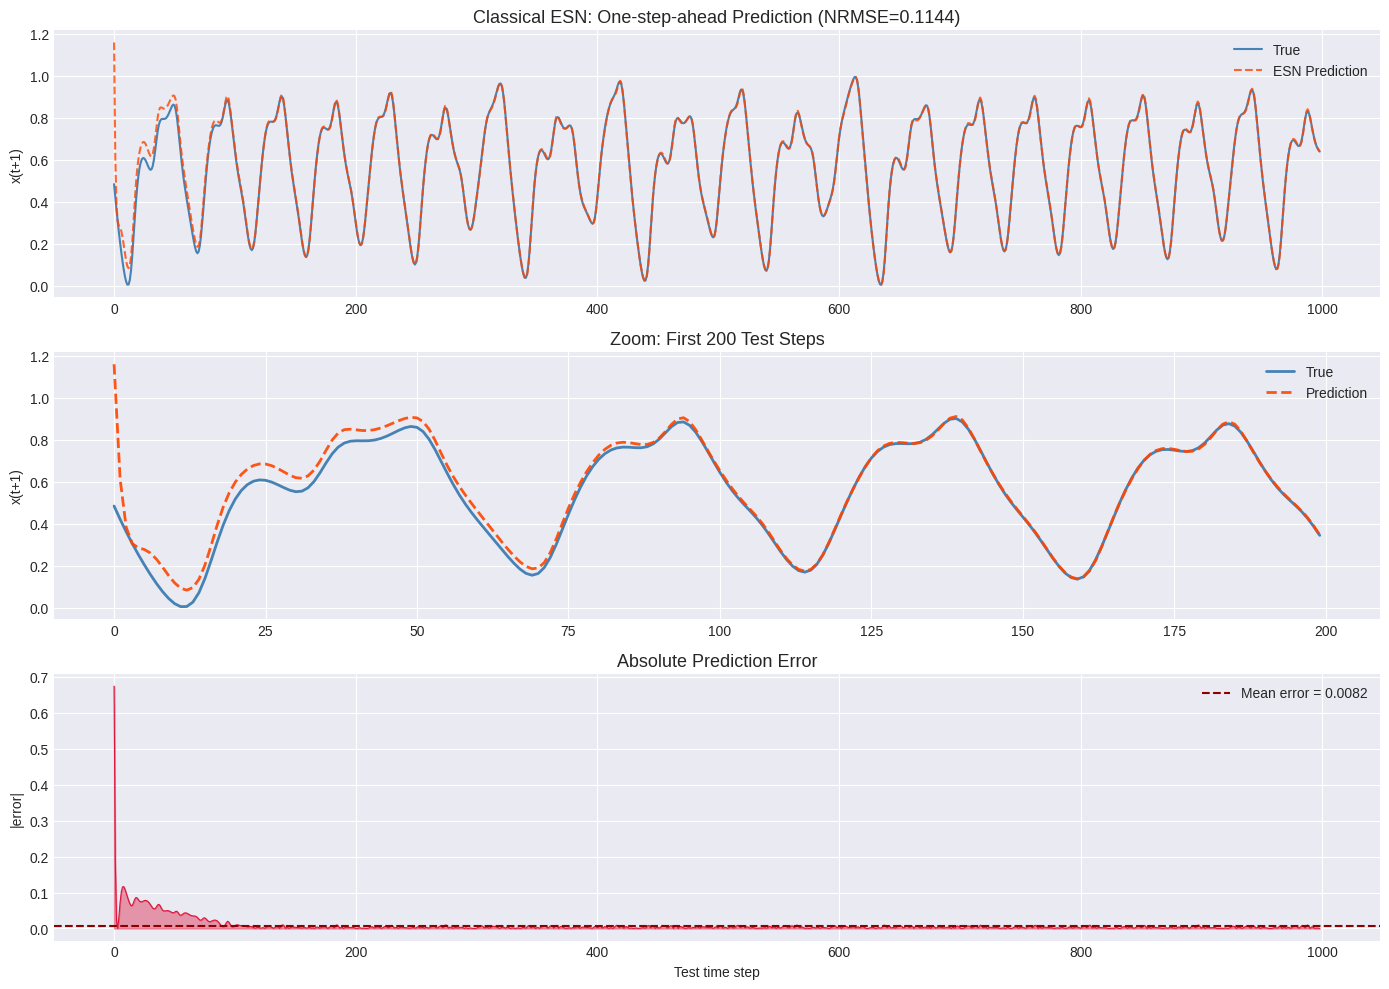

In [ ]:
# Predict on test set
y_pred = esn.predict(u_test)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
nrmse = test_rmse / np.std(y_test)  # Normalized RMSE

print(f'Test MSE  : {test_mse:.6f}')
print(f'Test RMSE : {test_rmse:.6f}')
print(f'NRMSE     : {nrmse:.4f}')

# Plot predictions
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Full comparison
t = np.arange(len(y_test))
axes[0].plot(t, y_test, label='True', color='steelblue', linewidth=1.5)
axes[0].plot(t, y_pred, label='ESN Prediction', color='orangered',
             linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].set_title(f'Classical ESN: One-step-ahead Prediction (NRMSE={nrmse:.4f})', fontsize=13)
axes[0].set_ylabel('x(t+1)')
axes[0].legend()

# Zoom in on first 200 steps
axes[1].plot(t[:200], y_test[:200], label='True', color='steelblue', linewidth=2)
axes[1].plot(t[:200], y_pred[:200], label='Prediction', color='orangered',
             linewidth=2, linestyle='--', alpha=0.9)
axes[1].set_title('Zoom: First 200 Test Steps', fontsize=13)
axes[1].set_ylabel('x(t+1)')
axes[1].legend()

# Error over time
error = np.abs(y_test - y_pred)
axes[2].fill_between(t, error, alpha=0.4, color='crimson')
axes[2].plot(t, error, color='crimson', linewidth=0.8)
axes[2].axhline(error.mean(), color='darkred', linestyle='--', label=f'Mean error = {error.mean():.4f}')
axes[2].set_title('Absolute Prediction Error', fontsize=13)
axes[2].set_xlabel('Test time step')
axes[2].set_ylabel('|error|')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Effect of Hyperparameters

Let's explore how key ESN parameters affect performance.

Reservoir built:
  Neurons        : 200
  Spectral radius: 0.1000
  Sparsity       : 89.93%
Training MSE: 0.000027
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.1737
  Sparsity       : 90.01%
Training MSE: 0.000015
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.2474
  Sparsity       : 90.08%
Training MSE: 0.000009
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.3211
  Sparsity       : 90.06%
Training MSE: 0.000008
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.3947
  Sparsity       : 90.09%
Training MSE: 0.000007
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.4684
  Sparsity       : 90.31%
Training MSE: 0.000005
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.5421
  Sparsity       : 90.04%
Training MSE: 0.000003
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.6158
  Sparsity       : 90.12%
Training MSE: 0.000002
Reservoir built:
  Neurons        : 200
  Spectral radius: 0.6895
  Sparsity    

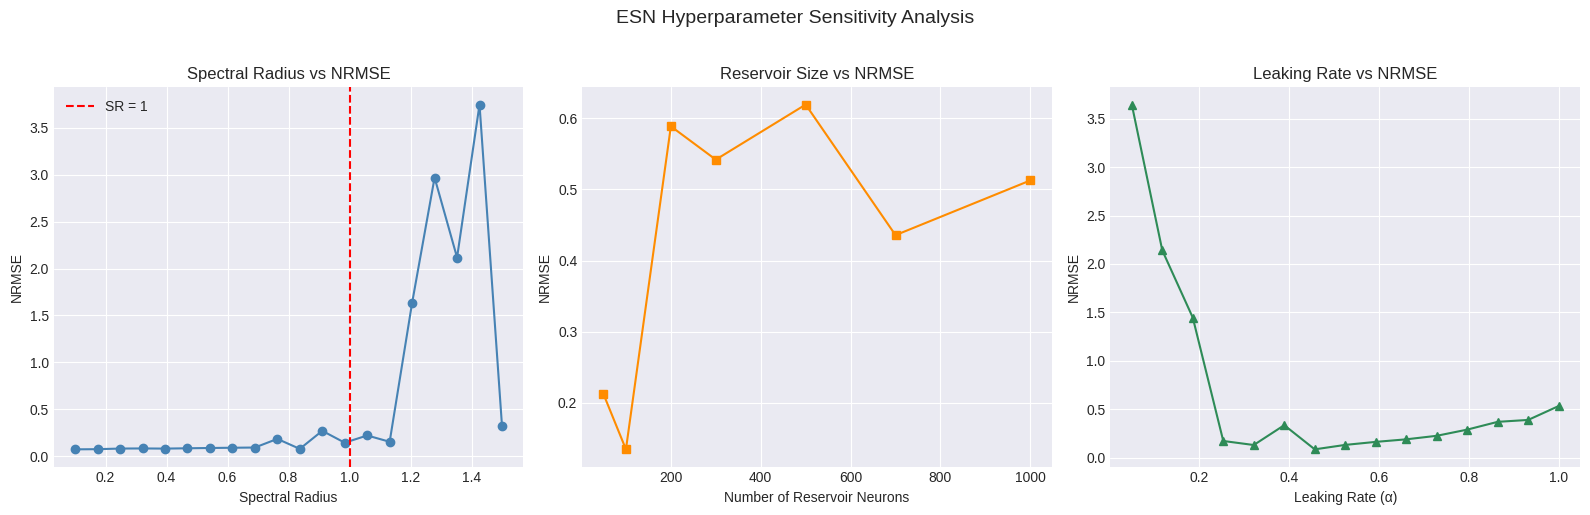

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---- Spectral Radius ----
sr_values = np.linspace(0.1, 1.5, 20)
nrmses_sr = []
for sr in sr_values:
    try:
        esn_temp = EchoStateNetwork(n_reservoir=200, spectral_radius=sr,
                                     leaking_rate=0.3, washout=100, ridge_alpha=1e-6)
        esn_temp.fit(u_train, y_train)
        pred = esn_temp.predict(u_test)
        nrmses_sr.append(np.sqrt(mean_squared_error(y_test, pred)) / np.std(y_test))
    except:
        nrmses_sr.append(np.nan)

axes[0].plot(sr_values, nrmses_sr, 'o-', color='steelblue')
axes[0].axvline(1.0, color='red', linestyle='--', label='SR = 1')
axes[0].set_title('Spectral Radius vs NRMSE')
axes[0].set_xlabel('Spectral Radius')
axes[0].set_ylabel('NRMSE')
axes[0].legend()

# ---- Reservoir Size ----
sizes = [50, 100, 200, 300, 500, 700, 1000]
nrmses_size = []
for n in sizes:
    esn_temp = EchoStateNetwork(n_reservoir=n, spectral_radius=0.95,
                                 leaking_rate=0.3, washout=100, ridge_alpha=1e-6)
    esn_temp.fit(u_train, y_train)
    pred = esn_temp.predict(u_test)
    nrmses_size.append(np.sqrt(mean_squared_error(y_test, pred)) / np.std(y_test))

axes[1].plot(sizes, nrmses_size, 's-', color='darkorange')
axes[1].set_title('Reservoir Size vs NRMSE')
axes[1].set_xlabel('Number of Reservoir Neurons')
axes[1].set_ylabel('NRMSE')

# ---- Leaking Rate ----
alphas = np.linspace(0.05, 1.0, 15)
nrmses_alpha = []
for a in alphas:
    esn_temp = EchoStateNetwork(n_reservoir=200, spectral_radius=0.95,
                                 leaking_rate=a, washout=100, ridge_alpha=1e-6)
    esn_temp.fit(u_train, y_train)
    pred = esn_temp.predict(u_test)
    nrmses_alpha.append(np.sqrt(mean_squared_error(y_test, pred)) / np.std(y_test))

axes[2].plot(alphas, nrmses_alpha, '^-', color='seagreen')
axes[2].set_title('Leaking Rate vs NRMSE')
axes[2].set_xlabel('Leaking Rate (α)')
axes[2].set_ylabel('NRMSE')

plt.suptitle('ESN Hyperparameter Sensitivity Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Visualizing the Reservoir States

We can visualize the rich internal representations the reservoir creates.

Reservoir built:
  Neurons        : 50
  Spectral radius: 0.9500
  Sparsity       : 89.80%
Training MSE: 0.000002


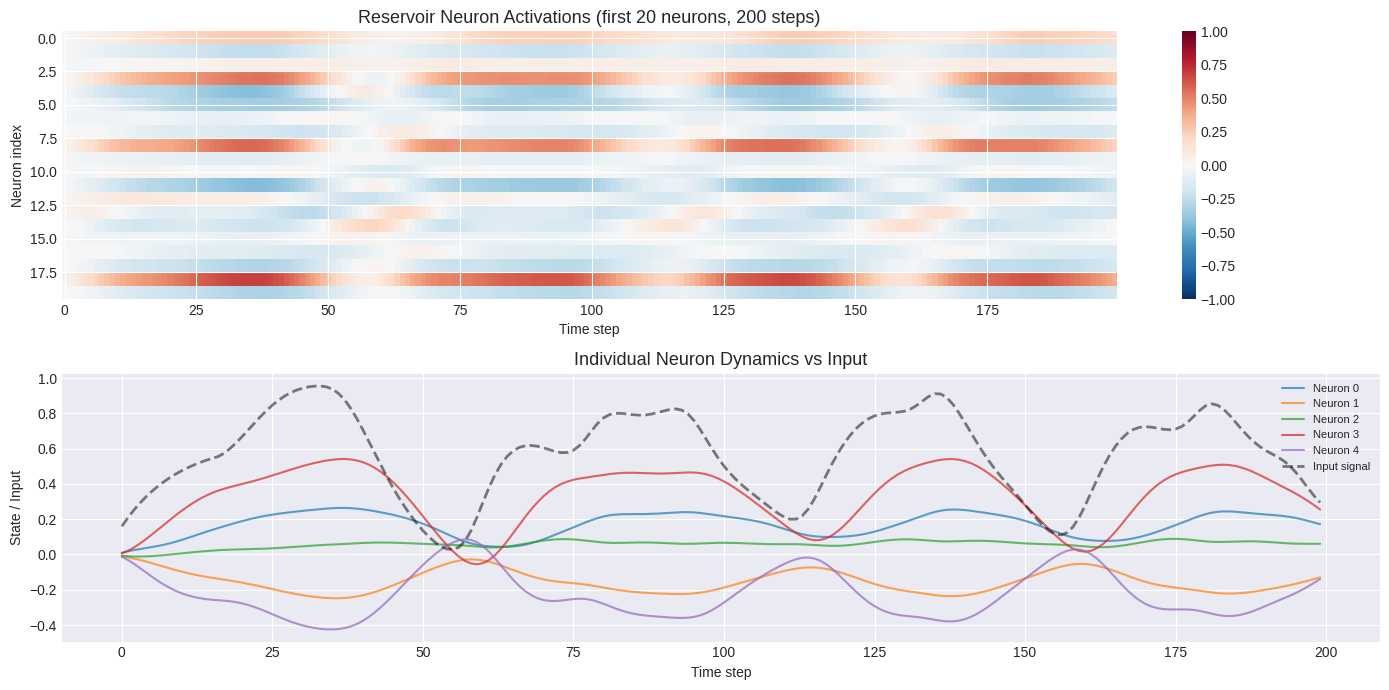

Notice how each neuron creates a different non-linear transformation of the input!


In [9]:
# Get reservoir states on a snippet of test data
esn_vis = EchoStateNetwork(n_reservoir=50, spectral_radius=0.95, leaking_rate=0.3)
esn_vis.fit(u_train, y_train)

# Manually run reservoir to collect states
T_vis = 300
states_vis = np.zeros((T_vis, 50))
x = np.zeros(50)
for t in range(T_vis):
    x = ((1 - 0.3) * x + 0.3 * np.tanh(
        esn_vis.W_in @ u_train[t] + esn_vis.W @ x))
    states_vis[t] = x

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Show activity of 20 reservoir neurons over time
im = axes[0].imshow(states_vis[:200, :20].T, aspect='auto', cmap='RdBu_r',
                    vmin=-1, vmax=1)
axes[0].set_title('Reservoir Neuron Activations (first 20 neurons, 200 steps)', fontsize=13)
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Neuron index')
plt.colorbar(im, ax=axes[0])

# Show a few individual neuron traces
for i in range(5):
    axes[1].plot(states_vis[:200, i], alpha=0.7, label=f'Neuron {i}')
axes[1].plot(u_train[:200, 0], 'k--', linewidth=2, label='Input signal', alpha=0.5)
axes[1].set_title('Individual Neuron Dynamics vs Input', fontsize=13)
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('State / Input')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()
print('Notice how each neuron creates a different non-linear transformation of the input!')

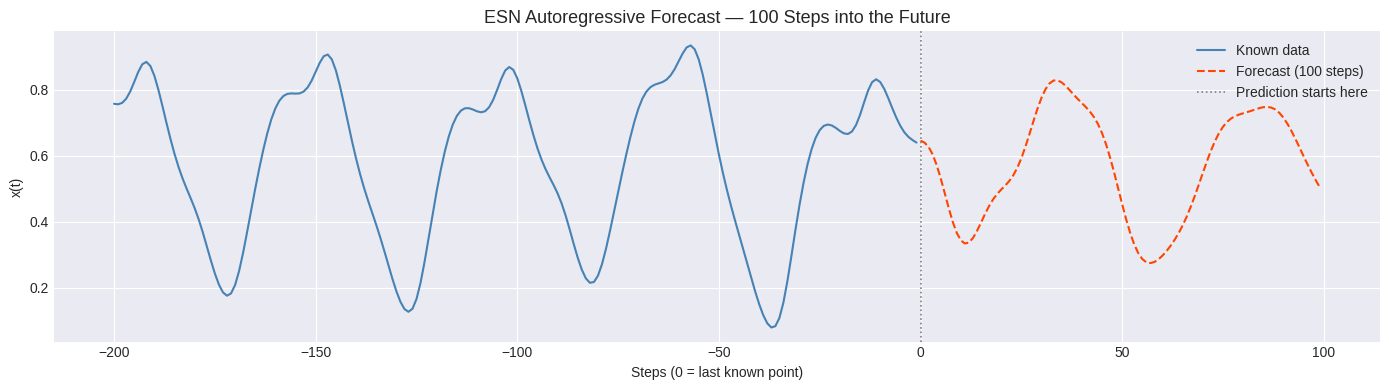

In [10]:
def forecast(esn, last_known_input, n_steps):
    """
    Generate n_steps predictions into the future using the trained ESN.

    Parameters
    ----------
    esn            : trained EchoStateNetwork instance
    last_known_input : the last real data point, shape (1, 1) or scalar
    n_steps        : how many future steps to predict

    Returns
    -------
    forecasts : array of shape (n_steps,) with future predictions
    """
    forecasts = []

    # Warm up the reservoir on ALL known training+test data first,
    # so it has a good internal state before we step into the future.
    # We do this by running _run_reservoir on the full u sequence.
    # Here we just carry forward the reservoir's last known state.

    # Get the reservoir's current state after seeing all real data
    # by running through the complete input sequence
    full_u = np.vstack([u_train, u_test])   # all real data seen so far
    states = esn._run_reservoir(full_u)
    x = states[-1]                          # last reservoir state — our starting point

    # The current input is the last real data point
    current_input = np.array([[last_known_input]])   # shape (1, 1)

    for step in range(n_steps):
        # One reservoir update step (same equation as _run_reservoir)
        x = ((1 - esn.alpha) * x
             + esn.alpha * np.tanh(esn.W_in @ current_input[0] + esn.W @ x))

        # Build extended state (reservoir state + raw input)
        extended = np.hstack([x, current_input[0]]).reshape(1, -1)

        # Readout: produce next prediction
        next_val = esn.readout.predict(extended)[0]
        forecasts.append(next_val)

        # Feed prediction back as next input ← this is the key step
        current_input = np.array([[next_val]])

    return np.array(forecasts)


# ── Run it ────────────────────────────────────────────────────────────────────
N_FUTURE = 100   # how many steps ahead you want

last_real_value = u_test[-1, 0]   # the very last known data point
future_preds    = forecast(esn, last_real_value, n_steps=N_FUTURE)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# Show the last 200 real test points for context
context = 200
t_past   = np.arange(-context, 0)
t_future = np.arange(0, N_FUTURE)

ax.plot(t_past,   y_test[-context:],  color='steelblue',   linewidth=1.5, label='Known data')
ax.plot(t_future, future_preds,        color='orangered',   linewidth=1.5,
        linestyle='--', label=f'Forecast ({N_FUTURE} steps)')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.2, label='Prediction starts here')

ax.set_title(f'ESN Autoregressive Forecast — {N_FUTURE} Steps into the Future', fontsize=13)
ax.set_xlabel('Steps (0 = last known point)')
ax.set_ylabel('x(t)')
ax.legend()
plt.tight_layout()
plt.show()